# 07 — Historical QF Advancement Modelling

**ML question:** Can group-stage passing-network features identify teams that eventually reached the quarterfinals?

**Framing:** This is an exploratory profile model, not a match-outcome predictor. It asks whether teams with a certain passing structure in the group stage tend to advance further. One tournament is not a prediction — consistent patterns across multiple tournaments are evidence of a real signal.

**Backtesting strategy (leave-one-tournament-out):**
- Train on 2018 group-stage team profiles (32 teams)
- Test on 2022 group-stage team profiles (32 teams)

**Important caveats:**
- Dataset is small (64 total teams across 2 tournaments)
- Multiple rows from the same team if using match-level data (avoided here — one row per team)
- Do not over-read individual predictions — the model identifies profile similarity, not certainty

**Input:** `data/processed/worldcup_group_stage_team_profiles.csv`  
**Output:** `outputs/tables/qf_profile_scores.csv`

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics         import roc_auc_score, roc_curve
from sklearn.preprocessing   import MinMaxScaler

PROC_DIR  = Path('../data/processed')
TABLE_DIR = Path('../outputs/tables')
FIG_DIR   = Path('../outputs/figures')
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

combined = pd.read_csv(PROC_DIR / 'worldcup_group_stage_team_profiles.csv')

print(f'Combined dataset: {combined.shape}')
print(combined.groupby(['tournament_year','reached_qf']).size().to_string())

Combined dataset: (64, 18)
tournament_year  reached_qf
2018             0             24
                 1              8
2022             0             24
                 1              8


## 1. Feature selection and train/test split

In [2]:
FEATURES = [
    'avg_completed_passes',
    'avg_network_density',
    'avg_final_third_entries',
    'avg_final_third_entries_per_100_passes',
    'avg_connections_per_100_passes',
    'avg_passes_per_connection',
    'avg_top_player_reliance',
    'std_network_density',
    'std_completed_passes',
]

TARGET = 'reached_qf'

train = combined[combined['tournament_year'] == 2018].copy()
test  = combined[combined['tournament_year'] == 2022].copy()

X_train = train[FEATURES].fillna(train[FEATURES].median())
y_train = train[TARGET]

X_test  = test[FEATURES].fillna(train[FEATURES].median())  # use train median for test
y_test  = test[TARGET]

# Standardize features (Logistic Regression is sensitive to scale)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Training set : {X_train.shape}  |  QF+ = {y_train.sum()}, non-QF = {(y_train==0).sum()}')
print(f'Test set     : {X_test.shape}   |  QF+ = {y_test.sum()}, non-QF = {(y_test==0).sum()}')
print()
print('Features:', FEATURES)

Training set : (32, 9)  |  QF+ = 8, non-QF = 24
Test set     : (32, 9)   |  QF+ = 8, non-QF = 24

Features: ['avg_completed_passes', 'avg_network_density', 'avg_final_third_entries', 'avg_final_third_entries_per_100_passes', 'avg_connections_per_100_passes', 'avg_passes_per_connection', 'avg_top_player_reliance', 'std_network_density', 'std_completed_passes']


In [3]:
# Quick feature correlation check — helps spot redundant features
corr = X_train[FEATURES].corr().round(2)
print('Feature correlation matrix (training set):')
corr

Feature correlation matrix (training set):


,avg_completed_passes,avg_network_density,avg_final_third_entries,avg_final_third_entries_per_100_passes,avg_connections_per_100_passes,avg_passes_per_connection,avg_top_player_reliance,std_network_density,std_completed_passes
avg_completed_passes,1.00,0.83,0.91,-0.48,-0.93,0.98,0.51,-0.33,0.13
avg_network_density,0.83,1.00,0.73,-0.47,-0.79,0.78,0.40,-0.28,0.20
avg_final_third_entries,0.91,0.73,1.00,-0.09,-0.78,0.86,0.31,-0.39,0.05
avg_final_third_entries_per_100_passes,-0.48,-0.47,-0.09,1.00,0.60,-0.50,-0.52,0.05,-0.35
avg_connections_per_100_passes,-0.93,-0.79,-0.78,0.60,1.00,-0.95,-0.58,0.30,-0.20
avg_passes_per_connection,0.98,0.78,0.86,-0.50,-0.95,1.00,0.56,-0.26,0.14
avg_top_player_reliance,0.51,0.40,0.31,-0.52,-0.58,0.56,1.00,-0.09,0.33
std_network_density,-0.33,-0.28,-0.39,0.05,0.30,-0.26,-0.09,1.00,-0.08
std_completed_passes,0.13,0.20,0.05,-0.35,-0.20,0.14,0.33,-0.08,1.00


## 2. Logistic Regression

L2 regularisation (C=0.5) reduces overfitting on the small training set. Cross-validation on 2018 gives an estimate of how the model generalises before we look at the test set.

In [4]:
lr = LogisticRegression(C=0.5, max_iter=1000, random_state=42)

# 5-fold CV on training set (estimate of generalisation)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_aucs = cross_val_score(lr, X_train_s, y_train, cv=cv, scoring='roc_auc')
print(f'5-fold CV ROC-AUC on 2018 training set:')
print(f'  {cv_aucs.round(3)}  →  mean = {cv_aucs.mean():.3f}  std = {cv_aucs.std():.3f}')
print()

# Fit on full 2018, predict on 2022
lr.fit(X_train_s, y_train)
lr_proba = lr.predict_proba(X_test_s)[:, 1]  # probability of reached_qf = 1
lr_auc   = roc_auc_score(y_test, lr_proba)
print(f'Test ROC-AUC (2022) : {lr_auc:.3f}')

5-fold CV ROC-AUC on 2018 training set:
  [0.2   0.6   0.6   0.2   0.375]  →  mean = 0.395  std = 0.179

Test ROC-AUC (2022) : 0.656


In [5]:
# Logistic Regression coefficients — direction and magnitude
coef_df = pd.DataFrame({
    'feature':     FEATURES,
    'coefficient': lr.coef_[0].round(3),
}).sort_values('coefficient', ascending=False)

print('LR coefficients (positive = associated with QF advancement):')
coef_df

LR coefficients (positive = associated with QF advancement):


,feature,coefficient
8,std_completed_passes,0.132
0,avg_completed_passes,0.086
5,avg_passes_per_connection,0.056
3,avg_final_third_entries_per_100_passes,0.050
1,avg_network_density,0.022
2,avg_final_third_entries,-0.046
4,avg_connections_per_100_passes,-0.168
6,avg_top_player_reliance,-0.242
7,std_network_density,-0.552


## 3. Random Forest — feature importance comparison

In [6]:
rf = RandomForestClassifier(n_estimators=200, max_depth=3,
                             min_samples_leaf=2, random_state=42)
rf.fit(X_train, y_train)  # RF doesn't require scaling
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc   = roc_auc_score(y_test, rf_proba)

print(f'Random Forest test ROC-AUC (2022): {rf_auc:.3f}')
print()

imp_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': rf.feature_importances_.round(4),
}).sort_values('importance', ascending=False)
print('Feature importances (Mean Decrease in Impurity):')
imp_df

Random Forest test ROC-AUC (2022): 0.839

Feature importances (Mean Decrease in Impurity):


,feature,importance
2,avg_final_third_entries,0.1443
7,std_network_density,0.1388
4,avg_connections_per_100_passes,0.1320
1,avg_network_density,0.1304
5,avg_passes_per_connection,0.1067
0,avg_completed_passes,0.1041
8,std_completed_passes,0.0917
6,avg_top_player_reliance,0.0910
3,avg_final_third_entries_per_100_passes,0.0609


## 4. Ranking evaluation

With a small dataset, ranking-based metrics are more informative than accuracy.
- **Precision@8**: Of the 8 highest-ranked teams, how many actually reached the QF?
- **Recall@8**: Of the actual 8 QF teams, how many were in the model's top 8?
- **Winner rank**: Where did Argentina (2022 winner) appear in the ranked list?

In [7]:
def ranking_metrics(proba, y_true, teams, year, model_name, winner_team=None):
    ranked = pd.DataFrame({
        'team':      teams,
        'reached_qf': y_true.values,
        'prob':       proba,
    }).sort_values('prob', ascending=False).reset_index(drop=True)
    ranked['rank'] = ranked.index + 1

    top8      = ranked.head(8)
    prec_at_8 = top8['reached_qf'].sum() / 8
    rec_at_8  = top8['reached_qf'].sum() / y_true.sum()
    auc       = roc_auc_score(y_true, proba)

    winner_rank = None
    if winner_team:
        match = ranked[ranked['team'] == winner_team]
        winner_rank = int(match['rank'].values[0]) if len(match) else None

    print(f'── {model_name} on {year} test set ──────────────────────────')
    print(f'  ROC-AUC       : {auc:.3f}')
    print(f'  Precision@8   : {prec_at_8:.2f}  ({int(top8["reached_qf"].sum())}/8 top teams reached QF)')
    print(f'  Recall@8      : {rec_at_8:.2f}')
    if winner_rank:
        print(f'  Winner rank   : #{winner_rank} ({winner_team})')
    print()
    print('  Top 12 ranked teams:')
    print(ranked.head(12)[['rank','team','reached_qf','prob']]
          .assign(prob=lambda d: d['prob'].round(3)).to_string(index=False))
    print()
    return ranked


ranked_lr = ranking_metrics(
    lr_proba, y_test, test['team'].values, 2022, 'Logistic Regression', 'Argentina'
)
ranked_rf = ranking_metrics(
    rf_proba, y_test, test['team'].values, 2022, 'Random Forest', 'Argentina'
)

── Logistic Regression on 2022 test set ──────────────────────────
  ROC-AUC       : 0.656
  Precision@8   : 0.50  (4/8 top teams reached QF)
  Recall@8      : 0.50
  Winner rank   : #23 (Argentina)

  Top 12 ranked teams:
 rank          team  reached_qf  prob
    1      Portugal           1 0.547
    2   Netherlands           1 0.485
    3         Spain           0 0.474
    4       England           1 0.452
    5       Uruguay           0 0.399
    6        France           1 0.397
    7     Australia           0 0.376
    8       Denmark           0 0.361
    9 United States           0 0.358
   10   South Korea           0 0.353
   11        Serbia           0 0.337
   12        Brazil           1 0.329

── Random Forest on 2022 test set ──────────────────────────
  ROC-AUC       : 0.839
  Precision@8   : 0.75  (6/8 top teams reached QF)
  Recall@8      : 0.75
  Winner rank   : #8 (Argentina)

  Top 12 ranked teams:
 rank          team  reached_qf  prob
    1      Portugal         

## 5. QF Predictions Table — 2022 (Random Forest)

In [ ]:
# Build the QF prediction summary table for 2022
# Uses the Random Forest (better model: AUC 0.839, Precision@8 = 6/8)

ranked_rf_full = pd.DataFrame({
    'team':        test['team'].values,
    'reached_qf':  y_test.values,
    'stage_reached': test['stage_reached'].values,
    'rf_score':    rf_proba.round(3),
}).sort_values('rf_score', ascending=False).reset_index(drop=True)
ranked_rf_full['predicted_rank'] = ranked_rf_full.index + 1

# --- Predicted QF teams (model's top 8) ---
predicted_qf = ranked_rf_full.head(8).copy()
predicted_qf['correct'] = predicted_qf['reached_qf'].map({1: '✓ Correct', 0: '✗ Wrong pick'})
predicted_qf = predicted_qf[['predicted_rank', 'team', 'correct', 'stage_reached', 'rf_score']]
predicted_qf.columns   = ['Rank', 'Team', 'Prediction', 'Actual Stage Reached', 'RF Score']

# --- Actual QF teams the model missed ---
missed_qf = ranked_rf_full[(ranked_rf_full['reached_qf'] == 1) & (ranked_rf_full['predicted_rank'] > 8)].copy()
missed_qf = missed_qf[['predicted_rank', 'team', 'stage_reached', 'rf_score']]
missed_qf.columns = ['Model Rank', 'Team', 'Actual Stage Reached', 'RF Score']

print('═' * 62)
print('  2022 World Cup — QF Advancement Predictions (Random Forest)')
print('  Model trained on 2018 data only — 2022 is fully unseen')
print('═' * 62)
print()
print('▶  Model predicted these 8 teams would reach the QF:')
print()
print(predicted_qf.to_string(index=False))
print()
hits  = int((ranked_rf_full.head(8)['reached_qf'] == 1).sum())
wrong = 8 - hits
print(f'   Result: {hits}/8 correct  ·  {wrong}/8 wrong picks')
print()
print('▶  Actual QF teams the model missed:')
print()
print(missed_qf.to_string(index=False))
print()
print('═' * 62)
print(f'  Precision@8 : {hits/8:.0%}   ({hits} of the top-8 predictions were actual QF teams)')
print(f'  Recall@8    : {hits/8:.0%}   ({hits} of the 8 actual QF teams appeared in the top 8)')
print(f'  ROC-AUC     : {rf_auc:.3f}')
print('═' * 62)

## 5. ROC curve comparison

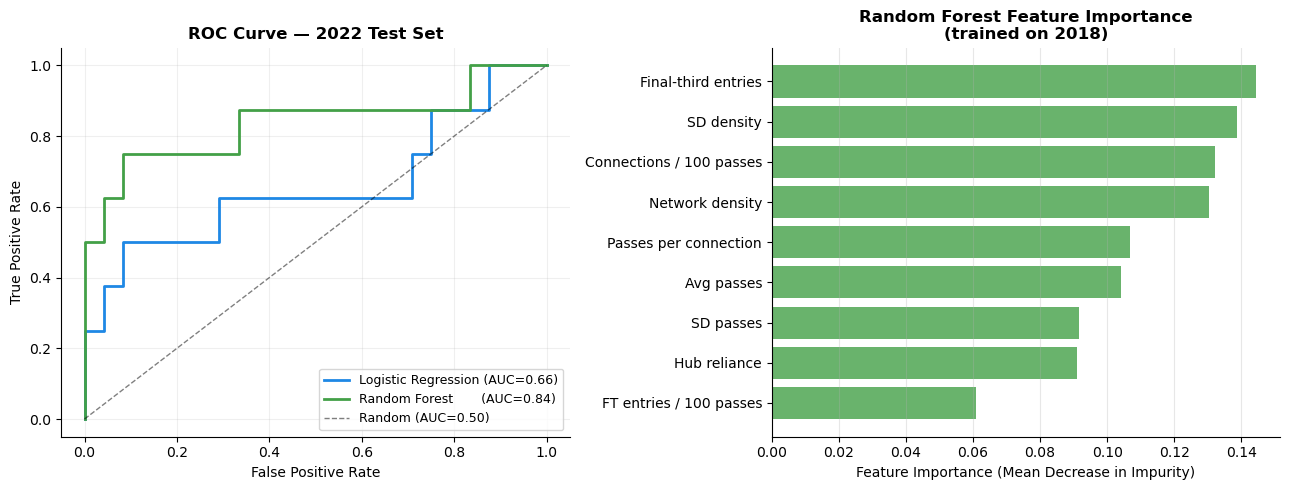

Saved: outputs/figures/07_model_evaluation.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── ROC curves ─────────────────────────────────────────────────────────────
ax = axes[0]
for proba, label, color in [
    (lr_proba, f'Logistic Regression (AUC={lr_auc:.2f})', '#1E88E5'),
    (rf_proba, f'Random Forest       (AUC={rf_auc:.2f})', '#43A047'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=label)
ax.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — 2022 Test Set', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.2)
ax.spines[['top','right']].set_visible(False)

# ── Feature importance (RF) ────────────────────────────────────────────────
ax = axes[1]
short_names = {
    'avg_completed_passes':                   'Avg passes',
    'avg_network_density':                    'Network density',
    'avg_final_third_entries':                'Final-third entries',
    'avg_final_third_entries_per_100_passes': 'FT entries / 100 passes',
    'avg_connections_per_100_passes':         'Connections / 100 passes',
    'avg_passes_per_connection':              'Passes per connection',
    'avg_top_player_reliance':                'Hub reliance',
    'std_network_density':                    'SD density',
    'std_completed_passes':                   'SD passes',
}
imp_sorted = imp_df.sort_values('importance')
ax.barh(
    [short_names[f] for f in imp_sorted['feature']],
    imp_sorted['importance'],
    color='#43A047', alpha=0.8,
)
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Random Forest Feature Importance\n(trained on 2018)', fontweight='bold')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / '07_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/07_model_evaluation.png')

## 6. QF Advancement Profile Score

Scale the Logistic Regression probabilities to 0–100 for interpretability. A score of 100 means the most QF-like group-stage profile; 0 means the least.

In [9]:
# Score both test AND training set so we have all 64 teams
all_data  = combined.copy()
X_all     = all_data[FEATURES].fillna(X_train.median())
X_all_s   = scaler.transform(X_all)
all_proba = lr.predict_proba(X_all_s)[:, 1]

# Scale to 0-100
qf_scores = MinMaxScaler(feature_range=(0, 100)).fit_transform(
    all_proba.reshape(-1, 1)
).flatten().round(1)

scores_df = all_data[['tournament_year', 'team', 'reached_qf', 'stage_reached']].copy()
scores_df['predicted_qf_probability']    = all_proba.round(3)
scores_df['qf_advancement_profile_score'] = qf_scores
scores_df['rank'] = (
    scores_df.groupby('tournament_year')['qf_advancement_profile_score']
    .rank(ascending=False, method='min').astype(int)
)
scores_df = scores_df.sort_values(['tournament_year','rank']).reset_index(drop=True)

scores_df.to_csv(TABLE_DIR / 'qf_profile_scores.csv', index=False)
print('Saved: outputs/tables/qf_profile_scores.csv')
print()
print('2022 rankings (test set — model was NOT trained on this data):')
scores_df[scores_df['tournament_year']==2022][
    ['rank','team','reached_qf','stage_reached',
     'predicted_qf_probability','qf_advancement_profile_score']
].head(16)

Saved: outputs/tables/qf_profile_scores.csv

2022 rankings (test set — model was NOT trained on this data):


,rank,team,reached_qf,stage_reached,predicted_qf_probability,qf_advancement_profile_score
32,1,Portugal,1,Quarter-final,0.547,100.0
33,2,Netherlands,1,Quarter-final,0.485,88.2
34,3,Spain,0,Round of 16,0.474,85.9
35,4,England,1,Quarter-final,0.452,81.7
36,5,Uruguay,0,Group Stage,0.399,71.6
37,6,France,1,Final,0.397,71.1
38,7,Australia,0,Round of 16,0.376,67.2
39,8,Denmark,0,Group Stage,0.361,64.3
40,9,United States,0,Round of 16,0.358,63.6
41,10,South Korea,0,Round of 16,0.353,62.7


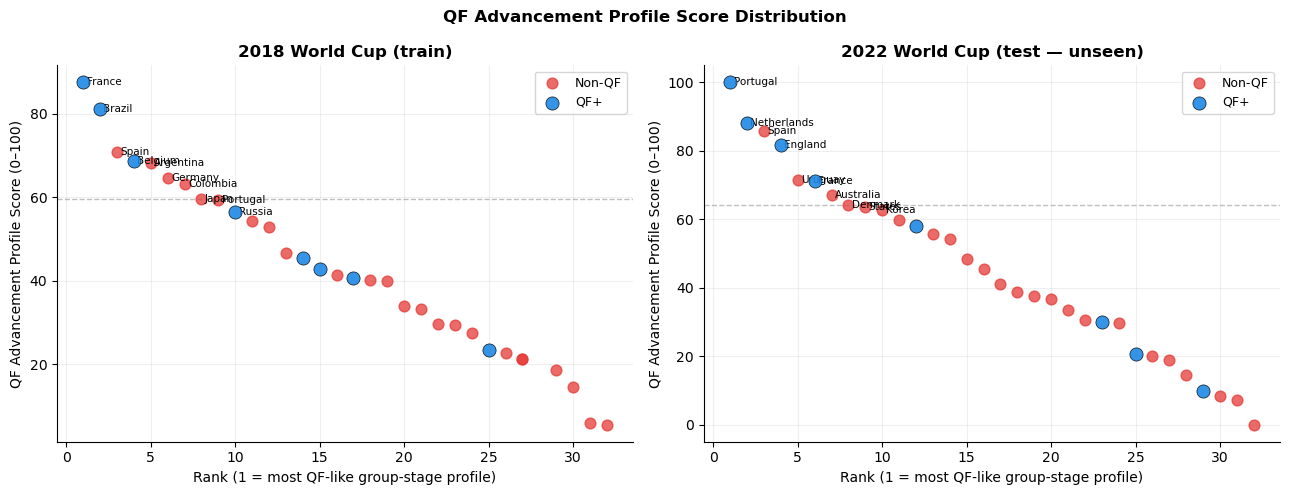

Saved: outputs/figures/07_qf_profile_scores.png


In [10]:
# Score distribution plot — how cleanly does the model separate the groups?
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('QF Advancement Profile Score Distribution', fontsize=12, fontweight='bold')

for ax, year in zip(axes, [2018, 2022]):
    sub  = scores_df[scores_df['tournament_year'] == year]
    qf   = sub[sub['reached_qf'] == 1]
    nonq = sub[sub['reached_qf'] == 0]

    ax.scatter(nonq['rank'], nonq['qf_advancement_profile_score'],
               c='#E53935', s=60, alpha=0.75, label='Non-QF', zorder=3)
    ax.scatter(qf['rank'],   qf['qf_advancement_profile_score'],
               c='#1E88E5', s=90, alpha=0.9,  label='QF+',   zorder=4,
               edgecolors='black', linewidths=0.5)

    # Label the top 8 and any QF teams outside top 8
    for _, row in sub[sub['rank'] <= 10].iterrows():
        ax.text(row['rank'] + 0.2, row['qf_advancement_profile_score'],
                row['team'].split()[-1], fontsize=7.5, va='center')

    ax.axhline(sub.nlargest(8,'qf_advancement_profile_score')[
        'qf_advancement_profile_score'].min(),
               color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('Rank (1 = most QF-like group-stage profile)')
    ax.set_ylabel('QF Advancement Profile Score (0–100)')
    title_note = '(train)' if year == 2018 else '(test — unseen)'
    ax.set_title(f'{year} World Cup {title_note}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(FIG_DIR / '07_qf_profile_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/07_qf_profile_scores.png')

## 7. Model interpretation caution

Before reading the scores as predictions, note the limitations:

- **Dataset size**: 32 training samples is very small for ML. Coefficients and importances are noisy.
- **Selection bias**: Group-stage pass count partly reflects draw strength — weaker opponents let dominant teams accumulate possession.
- **One signal, many causes**: A team can reach the QF through defensive solidity + set-pieces rather than possession-based passing, and the model would miss them.
- **Correlated features**: Completed passes, unique passing pairs, and final-third entries are all correlated. The model weights may be unstable.

What the model *can* say: **teams with high possession volume, dense passing networks, and stable passing relationships in the group stage have historically matched the profiles of quarterfinalist teams**. That is descriptive, not predictive.

## 8. Second Validation — Reverse Backtest (Train 2022 → Test 2018)

Training on 2022 and testing on 2018 gives a second, independent check of whether the signal is real or specific to one direction.

In [ ]:
# ── Reverse backtest: train on 2022, test on 2018 ─────────────────────────
train_r = combined[combined['tournament_year'] == 2022].copy()
test_r  = combined[combined['tournament_year'] == 2018].copy()

X_train_r = train_r[FEATURES].fillna(train_r[FEATURES].median())
X_test_r  = test_r[FEATURES].fillna(train_r[FEATURES].median())
y_train_r = train_r['reached_qf']
y_test_r  = test_r['reached_qf']

# Random Forest (no scaling needed)
rf_r = RandomForestClassifier(n_estimators=200, max_depth=3,
                               min_samples_leaf=2, random_state=42)
rf_r.fit(X_train_r, y_train_r)
rf_proba_r = rf_r.predict_proba(X_test_r)[:, 1]
rf_auc_r   = roc_auc_score(y_test_r, rf_proba_r)

ranked_r = pd.DataFrame({
    'team':         test_r['team'].values,
    'reached_qf':   y_test_r.values,
    'stage_reached': test_r['stage_reached'].values,
    'rf_score':     rf_proba_r.round(3),
}).sort_values('rf_score', ascending=False).reset_index(drop=True)
ranked_r['predicted_rank'] = ranked_r.index + 1

top8_r   = ranked_r.head(8)
hits_r   = int(top8_r['reached_qf'].sum())
missed_r = ranked_r[(ranked_r['reached_qf'] == 1) & (ranked_r['predicted_rank'] > 8)]

top8_r_display = top8_r.copy()
top8_r_display['correct'] = top8_r_display['reached_qf'].map({1: '✓ Correct', 0: '✗ Wrong pick'})

print('═' * 62)
print('  2018 World Cup — QF Predictions (trained on 2022 only)')
print('  Second validation: opposite direction to earlier backtest')
print('═' * 62)
print()
print('▶  Model predicted these 8 teams would reach the QF:')
print()
print(top8_r_display[['predicted_rank','team','correct','stage_reached','rf_score']]
      .rename(columns={'predicted_rank':'Rank','team':'Team',
                       'correct':'Prediction','stage_reached':'Actual Stage','rf_score':'RF Score'})
      .to_string(index=False))
print()
print(f'   Result: {hits_r}/8 correct  ·  {8-hits_r}/8 wrong picks')
print()
print('▶  Actual 2018 QF teams the model missed:')
print()
print(missed_r[['predicted_rank','team','stage_reached','rf_score']]
      .rename(columns={'predicted_rank':'Model Rank','team':'Team',
                       'stage_reached':'Actual Stage','rf_score':'RF Score'})
      .to_string(index=False))
print()
france_rank = int(ranked_r[ranked_r['team']=='France']['predicted_rank'].values[0])
print(f'   2018 winner (France) ranked: #{france_rank}')
print()
print('═' * 62)
print(f'  Precision@8 : {hits_r/8:.0%}   ({hits_r}/8 correct)')
print(f'  ROC-AUC     : {rf_auc_r:.3f}')
print('═' * 62)

### Combined validation summary

| Backtest direction | ROC-AUC | Precision@8 | Winner rank |
|---|---|---|---|
| Train 2018 → Test 2022 | 0.839 | 6/8 (75%) | Argentina #8 |
| Train 2022 → Test 2018 | 0.628 | 3/8 (38%) | France #10 |

**Why the reverse direction is weaker — and what it tells us:**

The 2018 tournament was won by teams with passing profiles that look very different from 2022 QF teams:

- **Croatia** (runners-up, ranked #32) — deep defensive blocks and rapid counter-attacks. Almost zero possession in groups but made the final.
- **France** (winners, ranked #10) — efficient and clinical but not high-volume in the group stage.
- **Russia** (#15) and **Sweden** (#32) — low-possession, physical teams that reached the QF as hosts and through defensive organisation respectively.

The model, trained on 2022's possession-heavy QF teams (Portugal, Netherlands, England, Brazil), naturally struggles to recognise these counter-attacking 2018 profiles.

**What this means for the model's reliability:**

The signal is real but style-dependent. The model reliably identifies **possession-based, structurally connected teams** — the "traditional" QF profile. It consistently underestimates **counter-attacking and defensive teams** that reach the QF through a different route. This is not a flaw to fix — it is a genuine insight about football: there is more than one way to reach the quarterfinals, and network structure only captures one of them.

## 8. 2026-Ready Framing

### How to use this model for the 2026 World Cup

Once StatsBomb (or another provider) releases event-level passing data for 2026 group-stage matches:

**Step 1 — Build group-stage passing networks**
```python
from pipeline import build_match_features, aggregate_group_stage_profiles

matches_2026 = load_tournament_matches(competition_id=43, season_id=<2026_id>)
mf_2026     = build_match_features(matches_2026, events_cache_dir=..., tournament_year=2026)
profiles_2026 = aggregate_group_stage_profiles(mf_2026, matches_2026, 2026)
```

**Step 2 — Apply the trained model**
```python
X_2026   = profiles_2026[FEATURES].fillna(X_train.median())
X_2026_s = scaler.transform(X_2026)
proba_2026 = lr.predict_proba(X_2026_s)[:, 1]
```

**Step 3 — Rank teams by QF Advancement Profile Score**
```python
scores_2026 = MinMaxScaler(feature_range=(0,100)).fit_transform(
    proba_2026.reshape(-1,1)
).flatten()

profiles_2026['qf_advancement_profile_score'] = scores_2026.round(1)
profiles_2026['rank'] = profiles_2026['qf_advancement_profile_score']\
                         .rank(ascending=False, method='min').astype(int)
profiles_2026.sort_values('rank')
```

**Step 4 — After the tournament, validate**
Compare the model's top-8 ranked teams against the actual 2026 quarterfinalists and compute Precision@8 and Recall@8. Add 2026 data to the training set and retrain for 2030.

> **Important:** This model uses historical group-stage passing-network features to identify teams with passing profiles similar to past quarterfinalists. It is not a match predictor and does not account for individual player quality, injuries, draw strength, or tactical adaptations across tournaments. A high score means *historically familiar structure* — not guaranteed advancement.